> **이 셀의 역할:** 노트북 전체 목표, 입·출력, Radar→LiDAR→Tracking→Risk 설계 철학을 한눈에 설명합니다.

# VoD End-to-End 규칙 기반 Radar-LiDAR-Tracking-Risk 파이프라인

이 노트북은 VoD 한 프레임(및 연속 프레임)을 입력으로 아래 출력을 생성합니다.

## 1) 목표 정의

### 입력
- Radar point cloud (VoD)
- LiDAR point cloud (동일 프레임)
- Camera image (동일 프레임)
- calibration / pose / annotation (있으면 활용)

### 출력
- 프레임별 표적 후보 목록
- 후보별 위치/거리/속도/신뢰도
- track id
- 위험도 점수
- 시각화 결과(BEV, camera overlay, 웹 JSON)

### 핵심 철학
- Radar: 먼저 의심스러운 움직임 후보를 찾는 1차 경보 센서
- LiDAR: 실제 형상 존재 여부를 검증하는 센서
- Tracking: 같은 물체를 시간축으로 묶는 모듈
- Risk: 가까움/접근 속도/진행축 정렬/검증 안정성을 점수화

즉, **Radar 1차 후보 생성 -> LiDAR 검증 -> Tracking -> Risk** 구조입니다.

> **이 셀의 역할:** 오프라인 준비·온라인 처리 단계와 모듈 경계(loaders~export)를 문서화합니다.

## 2) 권장 구조

### 2.1 오프라인 준비
- 프레임 인덱싱
- 센서 파일 매칭
- calibration / pose / label 경로 연결
- split(train/valid/test) 관리

### 2.2 온라인 처리
1. Radar 로드
2. Radar 전처리
3. DBSCAN 군집화(2D: x,y)
4. 후보 특징 계산
5. 후보 필터링 + 점수화
6. LiDAR 검증
7. 프레임 간 연관(Tracking)
8. 위험도 계산
9. 시각화(BEV/Camera overlay) + JSON 저장

### 2.3 모듈 경계
- loaders / geometry / preprocessing / clustering / filtering / validation / tracking / risk / visualization / export

In [1]:
# -----------------------------------------------------------------------------
# 셀 역할: 표준 라이브러리·NumPy·sklearn·matplotlib 로드, clip01/norm_linear 등 공통 유틸과(선택) 한글 폰트 설정.
# -----------------------------------------------------------------------------
from __future__ import annotations

import json
import math
import os
from collections import defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

# Windows 한글 폰트 (선택)
try:
    from matplotlib import font_manager, rc

    _fp = Path("C:/Windows/Fonts/malgun.ttf")
    if _fp.is_file():
        _fn = font_manager.FontProperties(fname=str(_fp)).get_name()
        rc("font", family=_fn)
        rc("axes", unicode_minus=False)
except Exception:
    pass


def clip01(x: float) -> float:
    return float(max(0.0, min(1.0, x)))


def norm_linear(x: float, lo: float, hi: float) -> float:
    if hi <= lo:
        return 0.0
    return clip01((x - lo) / (hi - lo))


def angle_diff_deg(a: float, b: float) -> float:
    d = (a - b + 180.0) % 360.0 - 180.0
    return abs(float(d))


def heading_from_v(vx: float, vy: float) -> float:
    return float(np.degrees(np.arctan2(vy, vx)))


print("imports ready")

imports ready


In [2]:
# -----------------------------------------------------------------------------
# 셀 역할: PipelineConfig(ROI·DBSCAN·트래킹·Risk 가중치 등) 정의 및 데이터셋 루트·cfg 인스턴스 생성.
# -----------------------------------------------------------------------------
@dataclass
class PipelineConfig:
    # 데이터 루트
    dataset_root: Path
    radar_scan_mode: str = "3-scan"  # single / 3-scan / 5-scan

    # split
    split_train: float = 0.7
    split_valid: float = 0.15

    # 시퀀스 실행
    start_idx: int = 0
    max_frames: int = 24
    dt_s: float = 0.1

    # Radar 전처리
    roi_x_min: float = 0.0
    roi_y_abs_max: float = 30.0
    roi_z_min: float = -2.0
    roi_z_max: float = 3.0
    dist_min: float = 2.0
    dist_max: float = 70.0
    abs_v_comp_min: float = 0.3
    rcs_clip_low: float = -40.0

    # DBSCAN (2D)
    dbscan_eps: float = 1.5
    dbscan_min_samples: int = 4

    # 후보 필터
    cand_min_points: int = 4
    cand_max_points: int = 80
    cand_dx_min: float = 0.5
    cand_dx_max: float = 8.0
    cand_dy_min: float = 0.5
    cand_dy_max: float = 5.0
    cand_dz_max: float = 4.0
    cand_speed_min: float = 0.3
    cand_dist_max: float = 70.0
    top_k_per_frame: int = 12

    # LiDAR 검증
    lidar_wx: float = 2.0
    lidar_wy: float = 2.0
    lidar_wz: float = 1.5
    lidar_min_points: int = 10

    # LiDAR DBSCAN — 정답(label_2 velo) 비교용 (레이더 DBSCAN과 별도 하이퍼파라미터)
    lidar_dbscan_eps: float = 0.85
    lidar_dbscan_min_samples: int = 8
    lidar_gt_match_thr_m: float = 2.0
    lidar_gt_min_points_per_cluster: int = 20
    lidar_gt_max_cluster_points: int = 8000
    lidar_cluster_max_extent_xy: float = 12.0
    lidar_cluster_max_extent_z: float = 5.0

    # Tracking 게이팅
    track_pos_gate_m: float = 4.0
    track_speed_gate_mps: float = 2.0
    track_heading_gate_deg: float = 20.0
    track_confirm_hits: int = 3
    track_max_missed: int = 3

    # Risk 가중치
    w_dist: float = 0.35
    w_approach: float = 0.30
    w_align: float = 0.15
    w_stability: float = 0.10
    w_valid: float = 0.10


NOTEBOOK_DIR = Path.cwd().resolve()
DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()

cfg = PipelineConfig(dataset_root=DATASET_ROOT)
print("dataset_root:", cfg.dataset_root)
print("exists:", cfg.dataset_root.is_dir())

dataset_root: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
exists: True


In [3]:
# -----------------------------------------------------------------------------
# 셀 역할: 레이더 모드별 디렉터리 선택, bin/라벨/캘리브 파서, 프레임 인덱스 구축 및 train/valid/test 인덱스 분할.
# -----------------------------------------------------------------------------
def choose_radar_dir(root: Path, mode: str) -> Path:
    candidates = {
        "single": [root / "radar" / "training" / "velodyne"],
        "3-scan": [
            root / "radar" / "training" / "velodyne_3",
            root / "radar" / "training" / "velodyne3",
            root / "radar" / "training" / "velodyne",
        ],
        "5-scan": [
            root / "radar" / "training" / "velodyne_5",
            root / "radar" / "training" / "velodyne5",
            root / "radar" / "training" / "velodyne",
        ],
    }
    for p in candidates.get(mode, []):
        if p.is_dir():
            return p
    fallback = root / "radar" / "training" / "velodyne"
    return fallback


def parse_radar_bin(path: Path) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.float32)
    if raw.size % 7 != 0:
        raise ValueError(f"Radar 파일 형식 오류(7배수 아님): {path}")
    return raw.reshape(-1, 7)


def parse_lidar_bin(path: Path) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.float32)
    if raw.size % 4 != 0:
        raise ValueError(f"LiDAR 파일 형식 오류(4배수 아님): {path}")
    return raw.reshape(-1, 4)


def parse_kitti_label(path: Path) -> list[dict[str, Any]]:
    if not path.is_file():
        return []
    rows: list[dict[str, Any]] = []
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = line.strip().split()
        if len(parts) < 15:
            continue
        cls = parts[0]
        h, w, l = map(float, parts[8:11])
        x, y, z = map(float, parts[11:14])
        ry = float(parts[14])
        rows.append(
            {
                "class": cls,
                "dims_hwl": [h, w, l],
                "center": [x, y, z],
                "yaw": ry,
            }
        )
    return rows


def parse_calib_txt(path: Path) -> dict[str, np.ndarray] | None:
    if not path.is_file():
        return None
    out: dict[str, np.ndarray] = {}
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        if ":" not in line:
            continue
        k, v = line.split(":", 1)
        vals = [float(x) for x in v.strip().split() if x]
        if vals:
            out[k.strip()] = np.array(vals, dtype=np.float64)
    return out if out else None


def build_frame_index(root: Path, radar_mode: str) -> tuple[list[dict[str, Any]], dict[str, Path]]:
    radar_dir = choose_radar_dir(root, radar_mode)
    lidar_dir = root / "lidar" / "training" / "velodyne"
    image_dir = root / "lidar" / "training" / "image_2"
    label_dir = root / "lidar" / "training" / "label_2"

    calib_candidates = [
        root / "lidar" / "training" / "calib",
        root / "lidar" / "training" / "calib_2",
        root / "calib",
    ]
    calib_dir = next((p for p in calib_candidates if p.is_dir()), None)

    pose_candidates = [
        root / "lidar" / "training" / "pose",
        root / "lidar" / "training" / "oxts",
        root / "pose",
    ]
    pose_dir = next((p for p in pose_candidates if p.is_dir()), None)

    if not (radar_dir.is_dir() and lidar_dir.is_dir() and image_dir.is_dir()):
        return [], {
            "radar_dir": radar_dir,
            "lidar_dir": lidar_dir,
            "image_dir": image_dir,
            "label_dir": label_dir,
            "calib_dir": calib_dir,
            "pose_dir": pose_dir,
        }

    radar_stems = {p.stem for p in radar_dir.glob("*.bin")}
    lidar_stems = {p.stem for p in lidar_dir.glob("*.bin")}
    image_stems = {p.stem for p in image_dir.glob("*.jpg")}
    common = sorted(radar_stems & lidar_stems & image_stems, key=lambda s: (0, int(s)) if s.isdigit() else (1, s))

    frames: list[dict[str, Any]] = []
    for stem in common:
        frames.append(
            {
                "frame_id": stem,
                "radar_path": radar_dir / f"{stem}.bin",
                "lidar_path": lidar_dir / f"{stem}.bin",
                "image_path": image_dir / f"{stem}.jpg",
                "label_path": (label_dir / f"{stem}.txt") if label_dir.is_dir() else None,
                "calib_path": (calib_dir / f"{stem}.txt") if calib_dir else None,
                "pose_path": (pose_dir / f"{stem}.txt") if pose_dir else None,
            }
        )

    return frames, {
        "radar_dir": radar_dir,
        "lidar_dir": lidar_dir,
        "image_dir": image_dir,
        "label_dir": label_dir,
        "calib_dir": calib_dir,
        "pose_dir": pose_dir,
    }


def split_indices(n: int, train_ratio: float, valid_ratio: float) -> dict[str, np.ndarray]:
    idx = np.arange(n, dtype=int)
    n_train = int(round(n * train_ratio))
    n_valid = int(round(n * valid_ratio))
    n_train = min(max(n_train, 0), n)
    n_valid = min(max(n_valid, 0), n - n_train)
    return {
        "train": idx[:n_train],
        "valid": idx[n_train : n_train + n_valid],
        "test": idx[n_train + n_valid :],
    }


frames_all, dirs_info = build_frame_index(cfg.dataset_root, cfg.radar_scan_mode)
splits = split_indices(len(frames_all), cfg.split_train, cfg.split_valid)

print("radar dir:", dirs_info["radar_dir"])
print("total synced frames:", len(frames_all))
print("split sizes:", {k: int(v.size) for k, v in splits.items()})
if frames_all:
    print("sample frame:", {k: str(v) if isinstance(v, Path) else v for k, v in frames_all[0].items()})

radar dir: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC\radar\training\velodyne
total synced frames: 8682
split sizes: {'train': 6077, 'valid': 1302, 'test': 1303}
sample frame: {'frame_id': '00000', 'radar_path': 'C:\\Users\\taehu\\Desktop\\projects\\hanhwa_final\\vod-devkit\\vod-received\\view_of_delft_PUBLIC\\radar\\training\\velodyne\\00000.bin', 'lidar_path': 'C:\\Users\\taehu\\Desktop\\projects\\hanhwa_final\\vod-devkit\\vod-received\\view_of_delft_PUBLIC\\lidar\\training\\velodyne\\00000.bin', 'image_path': 'C:\\Users\\taehu\\Desktop\\projects\\hanhwa_final\\vod-devkit\\vod-received\\view_of_delft_PUBLIC\\lidar\\training\\image_2\\00000.jpg', 'label_path': 'C:\\Users\\taehu\\Desktop\\projects\\hanhwa_final\\vod-devkit\\vod-received\\view_of_delft_PUBLIC\\lidar\\training\\label_2\\00000.txt', 'calib_path': 'C:\\Users\\taehu\\Desktop\\projects\\hanhwa_final\\vod-devkit\\vod-received\\view_of_delft_PUBLIC\\lidar\\training\\calib\\00000.t

In [4]:
# -----------------------------------------------------------------------------
# 셀 역할: 레이더 포인트 ROI·거리·도플러·RCS 마스킹 전처리 후, (x,y) DBSCAN으로 군집·후보별 특징·radar_conf 계산.
# -----------------------------------------------------------------------------
def preprocess_radar_points(pts: np.ndarray, cfg: PipelineConfig) -> tuple[np.ndarray, dict[str, int]]:
    if pts.size == 0:
        return pts, {"n_in": 0, "n_out": 0, "removed": 0}

    x = pts[:, 0]
    y = pts[:, 1]
    z = pts[:, 2]
    rcs = pts[:, 3]
    v_comp = pts[:, 5]
    d_xy = np.hypot(x, y)

    mask = (
        (x >= cfg.roi_x_min)
        & (np.abs(y) <= cfg.roi_y_abs_max)
        & (z >= cfg.roi_z_min)
        & (z <= cfg.roi_z_max)
        & (d_xy >= cfg.dist_min)
        & (d_xy <= cfg.dist_max)
        & (np.abs(v_comp) >= cfg.abs_v_comp_min)
        & (rcs >= cfg.rcs_clip_low)
    )

    out = pts[mask]
    return out, {"n_in": int(pts.shape[0]), "n_out": int(out.shape[0]), "removed": int(pts.shape[0] - out.shape[0])}


def cluster_radar_dbscan_2d(pts: np.ndarray, cfg: PipelineConfig) -> list[dict[str, Any]]:
    if pts.size == 0:
        return []

    xy = pts[:, :2]
    clustering = DBSCAN(eps=cfg.dbscan_eps, min_samples=cfg.dbscan_min_samples).fit(xy)
    labels = clustering.labels_

    clusters: list[dict[str, Any]] = []
    for label in sorted(set(labels.tolist())):
        if label < 0:
            continue
        m = labels == label
        cp = pts[m]
        if cp.size == 0:
            continue

        xyz = cp[:, :3]
        center = xyz.mean(axis=0)
        x, y, z = center.tolist()
        d = float(np.hypot(x, y))
        az = float(np.degrees(np.arctan2(y, x)))

        mins = xyz.min(axis=0)
        maxs = xyz.max(axis=0)
        ext = (maxs - mins).tolist()

        mean_rcs = float(cp[:, 3].mean())
        mean_v_comp = float(cp[:, 5].mean())
        n = int(cp.shape[0])

        # 기본 radar confidence
        conf = (
            0.35 * norm_linear(abs(mean_v_comp), 0.0, 8.0)
            + 0.25 * norm_linear(mean_rcs, -20.0, 30.0)
            + 0.25 * norm_linear(n, 3.0, 30.0)
            + 0.15 * (1.0 - norm_linear(d, cfg.dist_min, cfg.dist_max))
        )
        conf = clip01(conf)

        clusters.append(
            {
                "cluster_label": int(label),
                "center_xyz": [float(x), float(y), float(z)],
                "distance_m": round(d, 4),
                "azimuth_deg": round(az, 4),
                "n_points": n,
                "mean_rcs": round(mean_rcs, 4),
                "mean_v_comp": round(mean_v_comp, 4),
                "extent_xyz": [float(ext[0]), float(ext[1]), float(ext[2])],
                "radar_conf": round(conf, 4),
            }
        )
    return clusters


print("preprocess/clustering functions ready")

preprocess/clustering functions ready


In [ ]:
# -----------------------------------------------------------------------------
# 셀 역할: LiDAR 전처리(레이더와 동일 ROI) → 2D DBSCAN 군집 → KITTI label_2 정답(velodyne 좌표)과 중심거리 매칭·정밀도/재현율 출력.
# -----------------------------------------------------------------------------
KITTI_SKIP_CLASSES_EVAL = frozenset({"DontCare", "dontcare"})


def kitti_cam_rect_to_velo_points(
    xyz_cam: np.ndarray, calib: dict[str, np.ndarray]
) -> np.ndarray | None:
    """KITTI label의 3D 위치(rectified camera 좌표) (N,3) → velodyne (N,3)."""
    r0 = calib.get("R0_rect")
    tr = calib.get("Tr_velo_to_cam") or calib.get("Tr_velo_cam")
    if r0 is None or tr is None:
        return None
    R0 = np.eye(4, dtype=np.float64)
    R0[:3, :3] = np.asarray(r0, dtype=np.float64).reshape(3, 3)
    T = np.eye(4, dtype=np.float64)
    T[:3, :] = np.asarray(tr, dtype=np.float64).reshape(3, 4)
    M = R0 @ T
    Minv = np.linalg.inv(M)
    N = int(xyz_cam.shape[0])
    hom = np.hstack([xyz_cam.astype(np.float64), np.ones((N, 1), dtype=np.float64)])
    velo = (Minv @ hom.T).T[:, :3]
    return velo


def extract_kitti_gt_centers_velo(
    label_path: Path | None,
    calib: dict[str, np.ndarray] | None,
    skip_classes: frozenset[str] | None = None,
) -> tuple[np.ndarray, list[str]]:
    """label_2 + calib → velodyne 기준 GT 중심 (N,3), 클래스 이름."""
    skip = skip_classes or KITTI_SKIP_CLASSES_EVAL
    if label_path is None or not label_path.is_file() or calib is None:
        return np.zeros((0, 3), dtype=np.float64), []
    rows = parse_kitti_label(label_path)
    centers_cam: list[list[float]] = []
    classes: list[str] = []
    for r in rows:
        if r["class"] in skip:
            continue
        centers_cam.append([float(r["center"][0]), float(r["center"][1]), float(r["center"][2])])
        classes.append(str(r["class"]))
    if not centers_cam:
        return np.zeros((0, 3), dtype=np.float64), []
    cc = np.array(centers_cam, dtype=np.float64)
    velo = kitti_cam_rect_to_velo_points(cc, calib)
    if velo is None:
        return np.zeros((0, 3), dtype=np.float64), []
    return velo, classes


def preprocess_lidar_points(pts: np.ndarray, cfg: PipelineConfig) -> tuple[np.ndarray, dict[str, int]]:
    """레이더와 동일 ROI(거리·x,y,z)로 LiDAR 포인트 마스킹 — DBSCAN 입력."""
    if pts.size == 0:
        return pts, {"n_in": 0, "n_out": 0, "removed": 0}
    x = pts[:, 0]
    y = pts[:, 1]
    z = pts[:, 2]
    d_xy = np.hypot(x, y)
    mask = (
        (x >= cfg.roi_x_min)
        & (np.abs(y) <= cfg.roi_y_abs_max)
        & (z >= cfg.roi_z_min)
        & (z <= cfg.roi_z_max)
        & (d_xy >= cfg.dist_min)
        & (d_xy <= cfg.dist_max)
    )
    out = pts[mask]
    return out, {"n_in": int(pts.shape[0]), "n_out": int(out.shape[0]), "removed": int(pts.shape[0] - out.shape[0])}


def cluster_lidar_dbscan_2d(pts: np.ndarray, cfg: PipelineConfig) -> list[dict[str, Any]]:
    """LiDAR (x,y) 2D DBSCAN — 군집별 중심·extent."""
    if pts.size == 0:
        return []
    xy = pts[:, :2]
    clustering = DBSCAN(eps=cfg.lidar_dbscan_eps, min_samples=cfg.lidar_dbscan_min_samples).fit(xy)
    labels = clustering.labels_
    clusters: list[dict[str, Any]] = []
    for label in sorted(set(labels.tolist())):
        if label < 0:
            continue
        m = labels == label
        cp = pts[m]
        xyz = cp[:, :3]
        center = xyz.mean(axis=0)
        x, y, z = float(center[0]), float(center[1]), float(center[2])
        d = float(np.hypot(x, y))
        mins = xyz.min(axis=0)
        maxs = xyz.max(axis=0)
        ext = (maxs - mins).tolist()
        n = int(cp.shape[0])
        clusters.append(
            {
                "cluster_label": int(label),
                "center_xyz": [x, y, z],
                "distance_m": round(d, 4),
                "n_points": n,
                "extent_xyz": [float(ext[0]), float(ext[1]), float(ext[2])],
            }
        )
    return clusters


def filter_lidar_clusters_for_gt_eval(
    clusters: list[dict[str, Any]], cfg: PipelineConfig
) -> list[dict[str, Any]]:
    """도로면 거대 군집·노이즈 제거 후 정답 매칭용."""
    out: list[dict[str, Any]] = []
    for c in clusters:
        n = c["n_points"]
        if n < cfg.lidar_gt_min_points_per_cluster:
            continue
        if n > cfg.lidar_gt_max_cluster_points:
            continue
        dx, dy, dz = c["extent_xyz"]
        if max(dx, dy) > cfg.lidar_cluster_max_extent_xy or dz > cfg.lidar_cluster_max_extent_z:
            continue
        out.append(c)
    return out


def evaluate_centers_with_matches(
    dets: list[dict[str, Any]],
    gt_centers: np.ndarray,
    thr_m: float,
) -> dict[str, Any]:
    """검출 중심 ↔ GT 중심 greedy 1:1 매칭(거리 < thr_m), TP 평균 오차 포함."""
    if gt_centers.size == 0 and len(dets) == 0:
        return {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "precision": 1.0,
            "recall": 1.0,
            "f1": 1.0,
            "mean_tp_dist_m": None,
            "matches": [],
        }
    if len(dets) == 0:
        fn = int(gt_centers.shape[0])
        return {
            "tp": 0,
            "fp": 0,
            "fn": fn,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "mean_tp_dist_m": None,
            "matches": [],
        }
    det_xyz = np.array([d["center_xyz"] for d in dets], dtype=np.float64)
    used_gt: set[int] = set()
    matches: list[dict[str, Any]] = []
    for i in range(det_xyz.shape[0]):
        best_j: int | None = None
        best_d = thr_m
        for j in range(gt_centers.shape[0]):
            if j in used_gt:
                continue
            dd = float(np.linalg.norm(det_xyz[i] - gt_centers[j]))
            if dd < best_d:
                best_d = dd
                best_j = j
        if best_j is not None:
            used_gt.add(best_j)
            matches.append({"det_idx": int(i), "gt_idx": int(best_j), "dist_m": round(best_d, 4)})
    tp = len(matches)
    fp = int(det_xyz.shape[0] - tp)
    fn = int(gt_centers.shape[0] - tp)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    mean_dist = float(np.mean([m["dist_m"] for m in matches])) if matches else None
    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1": round(float(f1), 4),
        "mean_tp_dist_m": round(mean_dist, 4) if mean_dist is not None else None,
        "matches": matches,
    }


print("LiDAR DBSCAN / KITTI GT eval helpers ready")


In [5]:
# -----------------------------------------------------------------------------
# 셀 역할: 군집을 규칙으로 필터·점수화해 top-k 후보 선정, 후보별 LiDAR 로컬 박스 검증(점 수·extent·status).
# -----------------------------------------------------------------------------
def filter_and_rank_candidates(clusters: list[dict[str, Any]], cfg: PipelineConfig) -> list[dict[str, Any]]:
    out: list[dict[str, Any]] = []
    for c in clusters:
        n = c["n_points"]
        d = c["distance_m"]
        dx, dy, dz = c["extent_xyz"]
        mean_speed = abs(c["mean_v_comp"])
        mean_rcs = c["mean_rcs"]

        if not (cfg.cand_min_points <= n <= cfg.cand_max_points):
            continue
        if not (mean_speed >= cfg.cand_speed_min):
            continue
        if d > cfg.cand_dist_max:
            continue
        if not (cfg.cand_dx_min <= dx <= cfg.cand_dx_max):
            continue
        if not (cfg.cand_dy_min <= dy <= cfg.cand_dy_max):
            continue
        if dz > cfg.cand_dz_max:
            continue
        if mean_rcs < -35.0:
            continue

        score = (
            0.35 * norm_linear(mean_speed, 0.0, 8.0)
            + 0.25 * norm_linear(mean_rcs, -20.0, 30.0)
            + 0.25 * norm_linear(float(n), 3.0, 30.0)
            + 0.15 * (1.0 - norm_linear(d, cfg.dist_min, cfg.dist_max))
        )
        c2 = {**c, "candidate_score": round(clip01(score), 4)}
        out.append(c2)

    out.sort(key=lambda x: x["candidate_score"], reverse=True)
    return out[: cfg.top_k_per_frame]


def lidar_local_validation(candidate: dict[str, Any], lidar_pts: np.ndarray, cfg: PipelineConfig) -> dict[str, Any]:
    if lidar_pts.size == 0:
        return {
            "status": "radar_only",
            "lidar_points": 0,
            "lidar_extent_xyz": [0.0, 0.0, 0.0],
            "validated": False,
        }

    cx, cy, cz = candidate["center_xyz"]
    xyz = lidar_pts[:, :3]
    m = (
        (np.abs(xyz[:, 0] - cx) <= cfg.lidar_wx)
        & (np.abs(xyz[:, 1] - cy) <= cfg.lidar_wy)
        & (np.abs(xyz[:, 2] - cz) <= cfg.lidar_wz)
    )
    roi = xyz[m]
    n = int(roi.shape[0])

    if n == 0:
        return {
            "status": "radar_only",
            "lidar_points": 0,
            "lidar_extent_xyz": [0.0, 0.0, 0.0],
            "validated": False,
        }

    ext = (roi.max(axis=0) - roi.min(axis=0)).tolist()
    ex, ey, ez = [float(v) for v in ext]

    cond_points = n >= cfg.lidar_min_points
    cond_shape = (ex >= 0.4) and (ey >= 0.4) and (ez >= 0.5)

    if cond_points and cond_shape and n >= cfg.lidar_min_points * 2:
        status = "strong_validated"
    elif cond_points and cond_shape:
        status = "radar_lidar_validated"
    else:
        status = "radar_only"

    return {
        "status": status,
        "lidar_points": n,
        "lidar_extent_xyz": [round(ex, 4), round(ey, 4), round(ez, 4)],
        "validated": status != "radar_only",
    }


print("filter/lidar validation functions ready")

filter/lidar validation functions ready


In [6]:
# -----------------------------------------------------------------------------
# 셀 역할: 프레임 간 비용 게이팅으로 검출-트랙 연관, 트랙 상태(속도·heading·age·missed) 갱신 및 ID 부여.
# -----------------------------------------------------------------------------
def track_cost(track: dict[str, Any], det: dict[str, Any], cfg: PipelineConfig) -> tuple[float, dict[str, float]]:
    tx, ty, _ = track["center_xyz"]
    dx, dy, _ = det["center_xyz"]
    pos_dist = float(np.hypot(dx - tx, dy - ty))

    det_speed = abs(float(det["mean_v_comp"]))
    trk_speed = float(track.get("speed_mps", 0.0))
    speed_diff = abs(det_speed - trk_speed)

    trk_h = float(track.get("heading_deg", 0.0))
    det_h = float(np.degrees(np.arctan2(dy, dx)))
    head_diff = angle_diff_deg(det_h, trk_h)

    gated = (
        pos_dist <= cfg.track_pos_gate_m
        and speed_diff <= cfg.track_speed_gate_mps
        and head_diff <= cfg.track_heading_gate_deg
    )

    # 스케일 정규화
    cost = (
        0.60 * norm_linear(pos_dist, 0.0, cfg.track_pos_gate_m)
        + 0.25 * norm_linear(speed_diff, 0.0, cfg.track_speed_gate_mps)
        + 0.15 * norm_linear(head_diff, 0.0, cfg.track_heading_gate_deg)
    )
    return (cost if gated else 1e9), {
        "pos_dist": pos_dist,
        "speed_diff": speed_diff,
        "heading_diff": head_diff,
    }


def assign_tracks(
    detections: list[dict[str, Any]],
    active_tracks: dict[int, dict[str, Any]],
    next_track_id: int,
    cfg: PipelineConfig,
) -> tuple[list[dict[str, Any]], dict[int, dict[str, Any]], int]:
    # 1) 모든 track을 unmatched로 시작
    unmatched_tracks = set(active_tracks.keys())
    unmatched_dets = set(range(len(detections)))
    matches: list[tuple[int, int, dict[str, float]]] = []

    # 2) 전역 greedy(가장 낮은 cost부터)
    proposals: list[tuple[float, int, int, dict[str, float]]] = []
    for di, det in enumerate(detections):
        for tid, trk in active_tracks.items():
            c, detail = track_cost(trk, det, cfg)
            if c < 1e8:
                proposals.append((c, di, tid, detail))
    proposals.sort(key=lambda x: x[0])

    for c, di, tid, detail in proposals:
        if di in unmatched_dets and tid in unmatched_tracks:
            unmatched_dets.remove(di)
            unmatched_tracks.remove(tid)
            matches.append((di, tid, detail))

    # 3) 매칭된 detection -> track 업데이트
    for di, tid, detail in matches:
        det = detections[di]
        trk = active_tracks[tid]

        prev_center = np.array(trk["center_xyz"], dtype=np.float64)
        curr_center = np.array(det["center_xyz"], dtype=np.float64)
        vel = (curr_center - prev_center) / max(cfg.dt_s, 1e-6)
        vx, vy = float(vel[0]), float(vel[1])
        spd = float(np.hypot(vx, vy))
        hdg = heading_from_v(vx, vy)

        trk["center_xyz"] = det["center_xyz"]
        trk["velocity_xyz"] = [float(vel[0]), float(vel[1]), float(vel[2])]
        trk["speed_mps"] = spd
        trk["heading_deg"] = hdg
        trk["hits"] += 1
        trk["age"] += 1
        trk["missed"] = 0
        trk["confirmed"] = trk["hits"] >= cfg.track_confirm_hits
        trk["last_candidate_score"] = det["candidate_score"]
        trk["history"].append(det["center_xyz"])

        det["track_id"] = tid
        det["track_confirmed"] = trk["confirmed"]
        det["speed_mps"] = round(spd, 4)
        det["heading_deg"] = round(hdg, 2)
        det["track_age"] = trk["age"]
        det["assoc"] = {
            "matched": True,
            "pos_dist": round(detail["pos_dist"], 4),
            "speed_diff": round(detail["speed_diff"], 4),
            "heading_diff": round(detail["heading_diff"], 4),
        }

    # 4) 매칭 실패 detection -> 신규 track
    for di in sorted(unmatched_dets):
        det = detections[di]
        tid = next_track_id
        next_track_id += 1

        active_tracks[tid] = {
            "track_id": tid,
            "center_xyz": det["center_xyz"],
            "velocity_xyz": [0.0, 0.0, 0.0],
            "speed_mps": abs(float(det["mean_v_comp"])),
            "heading_deg": float(np.degrees(np.arctan2(det["center_xyz"][1], det["center_xyz"][0]))),
            "hits": 1,
            "age": 1,
            "missed": 0,
            "confirmed": False,
            "last_candidate_score": det["candidate_score"],
            "history": [det["center_xyz"]],
        }

        det["track_id"] = tid
        det["track_confirmed"] = False
        det["speed_mps"] = round(abs(float(det["mean_v_comp"])), 4)
        det["heading_deg"] = round(float(np.degrees(np.arctan2(det["center_xyz"][1], det["center_xyz"][0]))), 2)
        det["track_age"] = 1
        det["assoc"] = {"matched": False}

    # 5) 매칭 실패 track -> missed 증가, 오래 미관측이면 삭제
    to_delete = []
    for tid in sorted(unmatched_tracks):
        trk = active_tracks[tid]
        trk["missed"] += 1
        trk["age"] += 1
        if trk["missed"] >= cfg.track_max_missed:
            to_delete.append(tid)
    for tid in to_delete:
        del active_tracks[tid]

    return detections, active_tracks, next_track_id


print("tracking functions ready")

tracking functions ready


In [7]:
# -----------------------------------------------------------------------------
# 셀 역할: 검출별 위험도 점수·등급(Low~Critical) 산출, VoD radar JSON GT가 있으면 중심점 기반 검출 평가 헬퍼.
# -----------------------------------------------------------------------------
def compute_risk(det: dict[str, Any], cfg: PipelineConfig) -> dict[str, Any]:
    x, y, _ = det["center_xyz"]
    d = float(np.hypot(x, y))

    # 거리 위험 (가까울수록 큼)
    distance_score = clip01(math.exp(-d / 20.0))

    # 접근 위험 (원점 방향 성분)
    vx = float(det.get("velocity_xyz", [0.0, 0.0, 0.0])[0])
    vy = float(det.get("velocity_xyz", [0.0, 0.0, 0.0])[1])
    speed = float(np.hypot(vx, vy))
    approach_score = 0.0
    if d > 1e-6 and speed > 1e-6:
        to_origin = np.array([-x, -y], dtype=np.float64) / d
        v_dir = np.array([vx, vy], dtype=np.float64) / speed
        toward = max(0.0, float(np.dot(v_dir, to_origin)))
        approach_score = toward * clip01(speed / 20.0)
    else:
        # 속도 벡터가 약하면 v_comp로 대체 근사
        approach_score = clip01(abs(float(det.get("mean_v_comp", 0.0))) / 8.0) * 0.4

    # 진행축 정렬 위험 (전방 중심선에 가까울수록)
    align_x = clip01(norm_linear(x, 0.0, 35.0))
    align_y = 1.0 - clip01(abs(y) / 8.0)
    align_score = clip01(0.6 * align_x + 0.4 * align_y)

    # track 안정성
    age = int(det.get("track_age", 1))
    stable = clip01(norm_linear(float(age), 1.0, 6.0))
    if not bool(det.get("track_confirmed", False)):
        stable *= 0.8

    # LiDAR 검증
    v_status = det.get("validation", {}).get("status", "radar_only")
    valid_score = {
        "radar_only": 0.6,
        "radar_lidar_validated": 0.85,
        "strong_validated": 1.0,
    }.get(v_status, 0.6)

    risk = (
        cfg.w_dist * distance_score
        + cfg.w_approach * approach_score
        + cfg.w_align * align_score
        + cfg.w_stability * stable
        + cfg.w_valid * valid_score
    )
    risk = clip01(risk)

    if risk < 0.30:
        level = "Low"
    elif risk < 0.60:
        level = "Medium"
    elif risk < 0.80:
        level = "High"
    else:
        level = "Critical"

    return {
        "score": round(risk, 4),
        "level": level,
        "components": {
            "distance": round(distance_score, 4),
            "approach": round(approach_score, 4),
            "alignment": round(align_score, 4),
            "stability": round(stable, 4),
            "validation": round(valid_score, 4),
        },
    }


def load_radar_json_annotations(dataset_root: Path, frame_id: str) -> list[dict[str, Any]]:
    # VoD radar label json (있으면 사용)
    p = dataset_root / "radar" / "training" / "label_2" / f"{frame_id}.json"
    if not p.is_file():
        return []
    try:
        data = json.loads(p.read_text(encoding="utf-8"))
        if isinstance(data, list):
            return data
    except Exception:
        return []
    return []


def extract_gt_centers_radar_json(rows: list[dict[str, Any]]) -> np.ndarray:
    centers = []
    for r in rows:
        g = r.get("geometry", {})
        c = g.get("center", {})
        if all(k in c for k in ("x", "y", "z")):
            centers.append([float(c["x"]), float(c["y"]), float(c["z"])])
    if not centers:
        return np.zeros((0, 3), dtype=np.float64)
    return np.array(centers, dtype=np.float64)


def evaluate_detection_centers(dets: list[dict[str, Any]], gt_centers: np.ndarray, thr_m: float = 2.5) -> dict[str, Any]:
    if len(dets) == 0 and gt_centers.shape[0] == 0:
        return {"tp": 0, "fp": 0, "fn": 0, "precision": 1.0, "recall": 1.0, "f1": 1.0}
    if len(dets) == 0:
        fn = int(gt_centers.shape[0])
        return {"tp": 0, "fp": 0, "fn": fn, "precision": 0.0, "recall": 0.0, "f1": 0.0}

    det_xyz = np.array([d["center_xyz"] for d in dets], dtype=np.float64)
    used_gt: set[int] = set()
    tp = 0

    for i in range(det_xyz.shape[0]):
        best_j = None
        best_d = thr_m
        for j in range(gt_centers.shape[0]):
            if j in used_gt:
                continue
            dd = float(np.linalg.norm(det_xyz[i] - gt_centers[j]))
            if dd < best_d:
                best_d = dd
                best_j = j
        if best_j is not None:
            used_gt.add(best_j)
            tp += 1

    fp = int(det_xyz.shape[0] - tp)
    fn = int(gt_centers.shape[0] - tp)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1": round(float(f1), 4),
    }


print("risk/evaluation functions ready")

risk/evaluation functions ready


In [8]:
# -----------------------------------------------------------------------------
# 셀 역할: 단일 프레임 파이프라인(process_one_frame)과 시퀀스 루프(run_sequence: 트래킹·risk·집계 평가).
# -----------------------------------------------------------------------------
def parse_pose_txt(path: Path | None) -> dict[str, Any] | None:
    if path is None or not path.is_file():
        return None
    text = path.read_text(encoding="utf-8", errors="ignore").strip()
    if not text:
        return None
    vals = []
    for tok in text.replace("\n", " ").split():
        try:
            vals.append(float(tok))
        except ValueError:
            pass
    if not vals:
        return {"raw": text[:200]}
    return {"values": vals[:32]}


def process_one_frame(frame: dict[str, Any], cfg: PipelineConfig) -> tuple[list[dict[str, Any]], dict[str, Any]]:
    radar_pts = parse_radar_bin(frame["radar_path"])
    lidar_pts = parse_lidar_bin(frame["lidar_path"])

    radar_f, pre_meta = preprocess_radar_points(radar_pts, cfg)
    clusters = cluster_radar_dbscan_2d(radar_f, cfg)
    candidates = filter_and_rank_candidates(clusters, cfg)

    for c in candidates:
        c["validation"] = lidar_local_validation(c, lidar_pts, cfg)

    # 캘리브/포즈/라벨(있으면)
    calib = parse_calib_txt(frame["calib_path"]) if frame.get("calib_path") else None
    pose = parse_pose_txt(frame["pose_path"]) if frame.get("pose_path") else None

    gt_velo, gt_class_names = extract_kitti_gt_centers_velo(frame.get("label_path"), calib)
    lidar_roi, lidar_pre_meta = preprocess_lidar_points(lidar_pts, cfg)
    lidar_raw_clusters = cluster_lidar_dbscan_2d(lidar_roi, cfg)
    lidar_ev_clusters = filter_lidar_clusters_for_gt_eval(lidar_raw_clusters, cfg)
    lidar_dets_eval = [{"center_xyz": c["center_xyz"]} for c in lidar_ev_clusters]
    lidar_gt_eval = evaluate_centers_with_matches(
        lidar_dets_eval,
        gt_velo,
        thr_m=cfg.lidar_gt_match_thr_m,
    )
    lidar_gt_eval["n_gt"] = int(gt_velo.shape[0])
    lidar_gt_eval["n_clusters_raw"] = len(lidar_raw_clusters)
    lidar_gt_eval["n_clusters_filtered"] = len(lidar_ev_clusters)
    lidar_gt_eval["gt_classes"] = gt_class_names
    lidar_gt_eval["lidar_preprocess"] = lidar_pre_meta

    radar_label_rows = load_radar_json_annotations(cfg.dataset_root, frame["frame_id"])
    gt_centers = extract_gt_centers_radar_json(radar_label_rows)
    eval_det = evaluate_detection_centers(candidates, gt_centers, thr_m=2.5)

    meta = {
        "frame_id": frame["frame_id"],
        "n_radar_raw": int(radar_pts.shape[0]),
        "n_radar_pre": int(radar_f.shape[0]),
        "n_lidar": int(lidar_pts.shape[0]),
        "preprocess": pre_meta,
        "n_clusters": len(clusters),
        "n_candidates": len(candidates),
        "calib_loaded": calib is not None,
        "pose_loaded": pose is not None,
        "n_gt_radar_json": int(gt_centers.shape[0]),
        "det_eval": eval_det,
        "n_gt_kitti_velo": int(gt_velo.shape[0]),
        "lidar_dbscan_gt_eval": lidar_gt_eval,
    }

    return candidates, meta


def run_sequence(frames: list[dict[str, Any]], cfg: PipelineConfig) -> dict[str, Any]:
    active_tracks: dict[int, dict[str, Any]] = {}
    next_track_id = 1

    frames_out: list[dict[str, Any]] = []
    all_dets_flat: list[dict[str, Any]] = []

    agg_tp = agg_fp = agg_fn = 0
    eval_frames = 0
    agg_l_tp = agg_l_fp = agg_l_fn = 0
    eval_lidar_gt_frames = 0

    for frame in frames:
        dets, meta = process_one_frame(frame, cfg)
        dets, active_tracks, next_track_id = assign_tracks(dets, active_tracks, next_track_id, cfg)

        # track 상태를 detection에 반영 -> risk 계산
        for d in dets:
            tid = int(d["track_id"])
            trk = active_tracks.get(tid)
            if trk is not None:
                d["velocity_xyz"] = [float(v) for v in trk.get("velocity_xyz", [0.0, 0.0, 0.0])]
                d["speed_mps"] = round(float(trk.get("speed_mps", d.get("speed_mps", 0.0))), 4)
                d["heading_deg"] = round(float(trk.get("heading_deg", d.get("heading_deg", 0.0))), 2)
                d["track_age"] = int(trk.get("age", d.get("track_age", 1)))

            d["risk"] = compute_risk(d, cfg)

        frame_out = {
            "frame_id": frame["frame_id"],
            "paths": {
                "radar": str(frame["radar_path"]),
                "lidar": str(frame["lidar_path"]),
                "image": str(frame["image_path"]),
                "label": str(frame["label_path"]) if frame.get("label_path") else None,
                "calib": str(frame["calib_path"]) if frame.get("calib_path") else None,
                "pose": str(frame["pose_path"]) if frame.get("pose_path") else None,
            },
            "meta": meta,
            "detections": dets,
        }
        frames_out.append(frame_out)

        all_dets_flat.extend([{"frame_id": frame["frame_id"], **d} for d in dets])

        if int(meta.get("n_gt_radar_json", 0)) > 0:
            agg_tp += int(meta["det_eval"]["tp"])
            agg_fp += int(meta["det_eval"]["fp"])
            agg_fn += int(meta["det_eval"]["fn"])
            eval_frames += 1
        if int(meta.get("n_gt_kitti_velo", 0)) > 0:
            le = meta["lidar_dbscan_gt_eval"]
            agg_l_tp += int(le["tp"])
            agg_l_fp += int(le["fp"])
            agg_l_fn += int(le["fn"])
            eval_lidar_gt_frames += 1

    if eval_frames > 0:
        prec = agg_tp / max(agg_tp + agg_fp, 1)
        rec = agg_tp / max(agg_tp + agg_fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        aggregate_eval = {
            "tp": int(agg_tp),
            "fp": int(agg_fp),
            "fn": int(agg_fn),
            "precision": round(float(prec), 4),
            "recall": round(float(rec), 4),
            "f1": round(float(f1), 4),
            "frames_with_gt": int(eval_frames),
        }
    else:
        aggregate_eval = {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "precision": None,
            "recall": None,
            "f1": None,
            "frames_with_gt": 0,
            "note": "radar json GT가 없어 aggregate evaluation을 생략했습니다.",
        }

    if eval_lidar_gt_frames > 0:
        lp = agg_l_tp / max(agg_l_tp + agg_l_fp, 1)
        lr = agg_l_tp / max(agg_l_tp + agg_l_fn, 1)
        lf1 = 2 * lp * lr / max(lp + lr, 1e-9)
        aggregate_lidar_gt_eval = {
            "tp": int(agg_l_tp),
            "fp": int(agg_l_fp),
            "fn": int(agg_l_fn),
            "precision": round(float(lp), 4),
            "recall": round(float(lr), 4),
            "f1": round(float(lf1), 4),
            "frames_with_kitti_gt": int(eval_lidar_gt_frames),
            "note": "LiDAR DBSCAN 중심 vs KITTI label_2(velo 변환) 매칭",
        }
    else:
        aggregate_lidar_gt_eval = {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "precision": None,
            "recall": None,
            "f1": None,
            "frames_with_kitti_gt": 0,
            "note": "KITTI 라벨 또는 캘리브 없음 — LiDAR 정답 평가 생략",
        }

    cfg_dict = asdict(cfg)
    cfg_dict["dataset_root"] = str(cfg.dataset_root)

    return {
        "config": cfg_dict,
        "n_frames": len(frames_out),
        "frames": frames_out,
        "summary": {
            "total_detections": len(all_dets_flat),
            "aggregate_eval": aggregate_eval,
            "aggregate_lidar_gt_eval": aggregate_lidar_gt_eval,
            "active_tracks_last_frame": len(active_tracks),
            "max_track_id": int(next_track_id - 1),
        },
    }


print("frame processing / sequence runner ready")

frame processing / sequence runner ready


In [9]:
# -----------------------------------------------------------------------------
# 셀 역할: 선택한 split에서 연속 프레임을 실제 실행하고, 요약 통계·첫 검출 샘플을 콘솔에 출력.
# -----------------------------------------------------------------------------
RUN_SPLIT = os.environ.get("VOD_RUN_SPLIT", "train")  # train / valid / test

if len(frames_all) == 0:
    raise RuntimeError("동기 프레임을 찾지 못했습니다. VOD_ROOT 경로를 확인하세요.")

split_idx = splits.get(RUN_SPLIT, splits["train"])
if split_idx.size == 0:
    raise RuntimeError(f"선택한 split({RUN_SPLIT})에 프레임이 없습니다.")

s0 = int(np.clip(cfg.start_idx, 0, max(int(split_idx.size) - 1, 0)))
s1 = int(min(s0 + cfg.max_frames, split_idx.size))
sel = split_idx[s0:s1]
frames_run = [frames_all[int(i)] for i in sel]

print(f"run split={RUN_SPLIT}, frames={len(frames_run)}, idx range=[{s0}, {s1})")
print("first frame id:", frames_run[0]["frame_id"], "last:", frames_run[-1]["frame_id"])

results = run_sequence(frames_run, cfg)
print("summary:", json.dumps(results["summary"], ensure_ascii=False, indent=2))



print("\n--- LiDAR DBSCAN vs KITTI GT (프레임별, GT>0만) ---")
for fr in results["frames"]:
    m = fr["meta"]
    if int(m.get("n_gt_kitti_velo", 0)) <= 0:
        continue
    e = m["lidar_dbscan_gt_eval"]
    cls_preview = ",".join(e.get("gt_classes", [])[:5])
    if len(e.get("gt_classes", [])) > 5:
        cls_preview += "..."
    print(
        f"  {m['frame_id']}: P={e['precision']} R={e['recall']} F1={e['f1']} "
        f"TP/FP/FN={e['tp']}/{e['fp']}/{e['fn']} mean_tp_dist_m={e['mean_tp_dist_m']} "
        f"clusters_f={e['n_clusters_filtered']}/raw={e['n_clusters_raw']} GTcls=[{cls_preview}]"
    )
    if e.get("matches"):
        print("    matches (det_idx, gt_idx, dist_m):", e["matches"][:8], "..." if len(e["matches"]) > 8 else "")

lagg = results["summary"].get("aggregate_lidar_gt_eval")
if lagg:
    print("\naggregate LiDAR↔KITTI:", json.dumps(lagg, ensure_ascii=False, indent=2))

if results["frames"] and results["frames"][0]["detections"]:
    print("sample detection:")
    print(json.dumps(results["frames"][0]["detections"][0], ensure_ascii=False, indent=2)[:1500])

run split=train, frames=24, idx range=[0, 24)
first frame id: 00000 last: 00023


summary: {
  "total_detections": 52,
  "aggregate_eval": {
    "tp": 0,
    "fp": 0,
    "fn": 0,
    "precision": null,
    "recall": null,
    "f1": null,
    "frames_with_gt": 0,
    "note": "radar json GT가 없어 aggregate evaluation을 생략했습니다."
  },
  "active_tracks_last_frame": 3,
  "max_track_id": 30
}


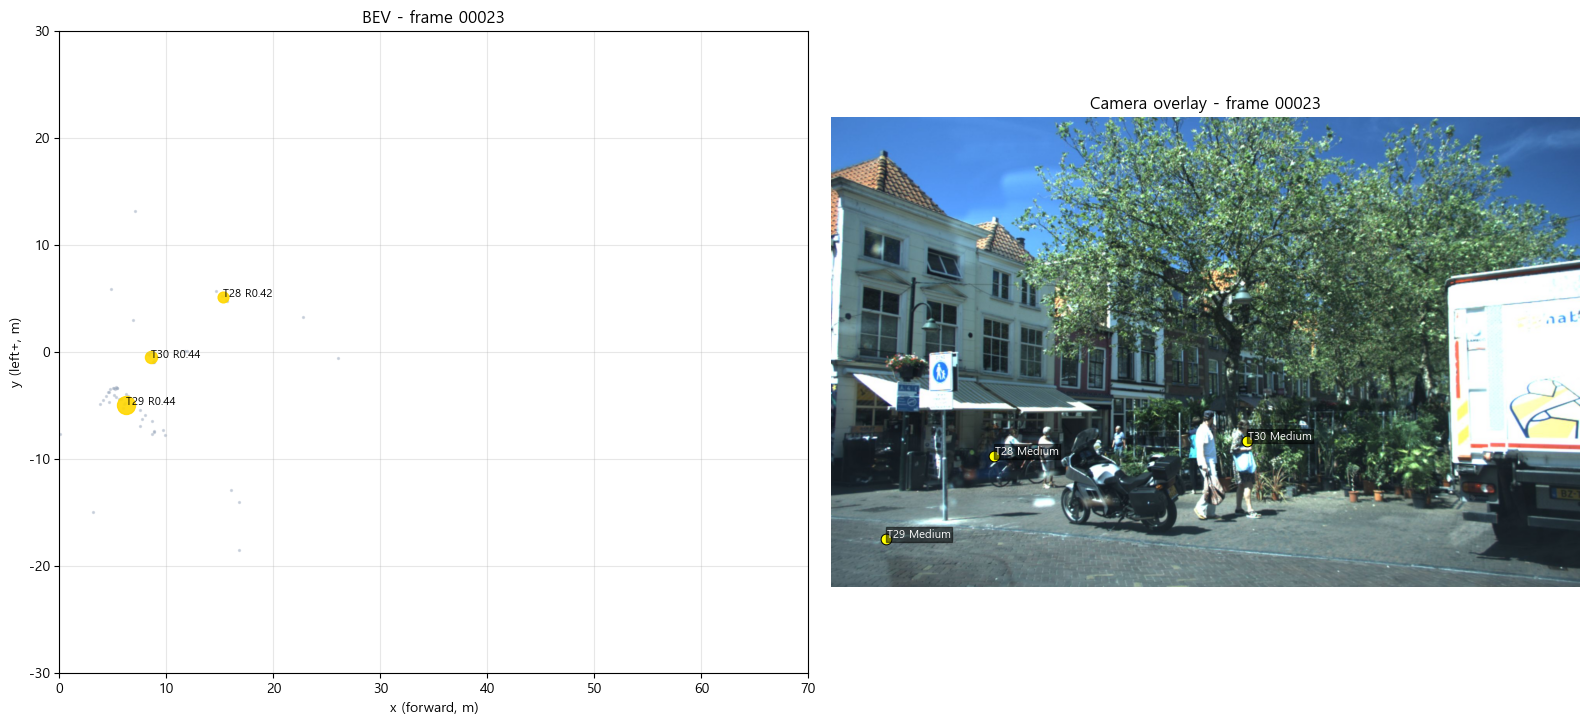

In [10]:
# -----------------------------------------------------------------------------
# 셀 역할: 캘리브를 이용한 카메라 투영 시도, BEV·이미지 오버레이 등 시각화(플롯)로 결과를 확인.
# -----------------------------------------------------------------------------
def try_project_with_calib(center_xyz: list[float], calib: dict[str, np.ndarray], w: int, h: int) -> tuple[float, float] | None:
    # 가능한 경우 P2 + Tr_velo_to_cam(or Tr_velo_cam)로 투영 시도
    if calib is None:
        return None
    p2 = calib.get("P2")
    tr = calib.get("Tr_velo_to_cam", calib.get("Tr_velo_cam"))
    if p2 is None:
        return None

    try:
        P2 = p2.reshape(3, 4)
        pt = np.array([center_xyz[0], center_xyz[1], center_xyz[2], 1.0], dtype=np.float64)

        if tr is not None and tr.size == 12:
            Tr = tr.reshape(3, 4)
            cam = Tr @ pt
            cam_h = np.array([cam[0], cam[1], cam[2], 1.0], dtype=np.float64)
        else:
            # Tr이 없으면 원좌표를 바로 투영(정확도 낮음, 실패 시 None 처리)
            cam_h = pt

        uvw = P2 @ cam_h
        if uvw[2] <= 1e-6:
            return None
        u = float(uvw[0] / uvw[2])
        v = float(uvw[1] / uvw[2])
        if -0.1 * w <= u <= 1.1 * w and -0.1 * h <= v <= 1.1 * h:
            return (u, v)
        return None
    except Exception:
        return None


def fallback_hud_projection(az_deg: float, dist_m: float, w: int, h: int, max_range: float) -> tuple[float, float]:
    # 캘리브 미사용/실패 시, 방위-거리 기반 HUD 스타일 근사 오버레이
    fov_deg = 90.0
    u = (az_deg / fov_deg + 0.5) * w
    u = float(np.clip(u, 0, w - 1))
    v = h - (dist_m / max(max_range, 1.0)) * h * 0.9
    v = float(np.clip(v, 0, h - 1))
    return u, v


VIS_FRAME_OFFSET = -1  # 마지막 프레임
vf = results["frames"][VIS_FRAME_OFFSET]
frame_id = vf["frame_id"]
img = plt.imread(vf["paths"]["image"]) if vf["paths"]["image"] else None

# BEV용 원시 점 재로드
radar_raw = parse_radar_bin(Path(vf["paths"]["radar"]))
radar_pre, _ = preprocess_radar_points(radar_raw, cfg)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (A) BEV
ax = axes[0]
if radar_pre.size > 0:
    ax.scatter(radar_pre[:, 0], radar_pre[:, 1], s=2, c="#94a3b8", alpha=0.35, label="radar preprocessed")
for d in vf["detections"]:
    cx, cy, _ = d["center_xyz"]
    risk = d["risk"]["score"]
    color = "red" if risk >= 0.8 else ("orange" if risk >= 0.6 else ("gold" if risk >= 0.3 else "green"))
    ax.scatter(cx, cy, s=40 + 4 * d["n_points"], c=color, alpha=0.9)
    ax.annotate(f"T{d['track_id']} R{risk:.2f}", (cx, cy), fontsize=8)
ax.set_title(f"BEV - frame {frame_id}")
ax.set_xlabel("x (forward, m)")
ax.set_ylabel("y (left+, m)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, cfg.dist_max)
ax.set_ylim(-cfg.roi_y_abs_max, cfg.roi_y_abs_max)

# (B) Camera overlay
ax2 = axes[1]
if img is not None:
    ax2.imshow(img)
    h, w = img.shape[:2]
    calib = parse_calib_txt(Path(vf["paths"]["calib"])) if vf["paths"].get("calib") else None

    for d in vf["detections"]:
        uv = try_project_with_calib(d["center_xyz"], calib, w, h)
        if uv is None:
            uv = fallback_hud_projection(d["azimuth_deg"], d["distance_m"], w, h, cfg.dist_max)
        u, v = uv
        risk = d["risk"]["score"]
        color = "red" if risk >= 0.8 else ("orange" if risk >= 0.6 else ("yellow" if risk >= 0.3 else "lime"))
        ax2.scatter([u], [v], c=color, s=60, edgecolors="black", linewidths=0.7)
        ax2.text(u + 4, v - 4, f"T{d['track_id']} {d['risk']['level']}", color="white", fontsize=8,
                 bbox=dict(facecolor="black", alpha=0.5, pad=1))

    ax2.set_title(f"Camera overlay - frame {frame_id}")
    ax2.axis("off")
else:
    ax2.text(0.5, 0.5, "image 없음", ha="center", va="center")
    ax2.set_axis_off()

plt.tight_layout()
plt.show()

In [11]:
# -----------------------------------------------------------------------------
# 셀 역할: 전체 results를 JSON으로 저장하고, 웹/데모용 경량 payload(vod_rule_pipeline_web.json)를 함께보냄.
# -----------------------------------------------------------------------------
OUT_DIR = NOTEBOOK_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)
out_json = OUT_DIR / "vod_rule_pipeline_results.json"
out_web_json = OUT_DIR / "vod_rule_pipeline_web.json"

# 원본 결과 저장
out_json.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")

# 웹 전달용 최소 포맷
web_rows = []
for fr in results["frames"]:
    for d in fr["detections"]:
        web_rows.append(
            {
                "frameId": fr["frame_id"],
                "trackId": d["track_id"],
                "x": round(float(d["center_xyz"][0]), 4),
                "y": round(float(d["center_xyz"][1]), 4),
                "z": round(float(d["center_xyz"][2]), 4),
                "rangeM": d["distance_m"],
                "azimuthDeg": d["azimuth_deg"],
                "speedMps": d.get("speed_mps"),
                "confidence": d["candidate_score"],
                "riskScore": d["risk"]["score"],
                "riskLevel": d["risk"]["level"],
                "validationStatus": d.get("validation", {}).get("status", "radar_only"),
            }
        )

web_payload = {
    "meta": {
        "source": "VoD rule pipeline",
        "nFrames": results["n_frames"],
        "nRows": len(web_rows),
    },
    "detections": web_rows,
}
out_web_json.write_text(json.dumps(web_payload, ensure_ascii=False, indent=2), encoding="utf-8")

# 상위 위험도 출력
top = sorted(web_rows, key=lambda r: r["riskScore"], reverse=True)[:10]
print("saved:", out_json)
print("saved:", out_web_json)
print("top-10 risky detections")
for r in top:
    print(r["frameId"], "T", r["trackId"], "risk", r["riskScore"], r["riskLevel"], "range", r["rangeM"], "valid", r["validationStatus"])

saved: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\outputs\vod_rule_pipeline_results.json
saved: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\outputs\vod_rule_pipeline_web.json
top-10 risky detections
00007 T 8 risk 0.7186 High range 8.7926 valid strong_validated
00007 T 7 risk 0.6202 High range 15.4468 valid strong_validated
00006 T 5 risk 0.4569 Medium range 12.0473 valid strong_validated
00023 T 30 risk 0.4444 Medium range 8.6164 valid strong_validated
00023 T 29 risk 0.442 Medium range 7.9703 valid strong_validated
00009 T 11 risk 0.4402 Medium range 7.0625 valid strong_validated
00005 T 6 risk 0.4357 Medium range 7.4239 valid strong_validated
00008 T 11 risk 0.4327 Medium range 7.1367 valid strong_validated
00010 T 13 risk 0.4327 Medium range 6.9683 valid strong_validated
00012 T 18 risk 0.4297 Medium range 7.1222 valid strong_validated


> **이 셀의 역할:** 실행 시 환경 변수(`VOD_ROOT`, `VOD_RUN_SPLIT`), 튜닝 포인트, baseline 한계를 정리합니다.

## 실행/튜닝 메모

- 데이터 루트 변경: `VOD_ROOT` 환경변수 사용
- split 변경: `VOD_RUN_SPLIT=train|valid|test`
- 프레임 수 변경: `cfg.max_frames`
- 추천 시작값(요청 반영):
  - 전처리: `x>=0`, `|y|<=30`, `z[-2,3]`, `distance[2,70]`, `|v_comp|>0.3`
  - DBSCAN: `x,y` 2D, `eps=1.5`, `min_samples=4`
  - Tracking 게이트: 위치 4m, 속도 2m/s, heading 20도
  - Risk 가중치: distance 35%, approach 30%, alignment 15%, stability 10%, validation 10%

이 노트북은 baseline 성격의 규칙 기반 구현입니다. 이후 개선은 `Kalman + Hungarian`, 거리 구간별 `DBSCAN eps` 조정, 카메라 정밀 투영/박스 연동 순으로 진행하면 좋습니다.

## 6) 딥러닝 학습 파이프라인 (label_2 기준)

위쪽 **규칙·DBSCAN·threshold** 는 **가중치 학습이 아닌 수동 튜닝**입니다.

아래는 **별도 모듈** `bev_lidar_detector_train.py` 로 구현한 **최소 학습 파이프라인**입니다.

| 단계 | 내용 |
|------|------|
| A. 데이터 | 동기 프레임의 LiDAR bin + `label_2` + calib → BEV 텐서(2채널) + 클래스별 가우시안 히트맵 타깃 |
| B. 모델 | `TinyBevDetector` — 소형 BEV CNN (BatchNorm + Conv), 출력 채널=3 (Vehicle / Pedestrian / Cyclist) |
| C. 학습 | `BCEWithLogitsLoss` + Adam, `pos_weight` 로 희소 양성 완화 |
| D. 평가 | 검증 세트에서 **sigmoid 히트맵 → 국소 피크 → velodyne (x,y)** , `label_2` GT 중심과 **거리 greedy 매칭** 후 **Precision / Recall / F1** (micro + 클래스별). (COCO 스타일 **mAP** 는 별도 구현 필요) |

출력 JSON: `outputs/bev_lidar_train_metrics.json`

환경 변수(선택): `BEV_MAX_TRAIN`, `BEV_MAX_VAL`, `BEV_EPOCHS`, `BEV_BATCH`


In [ ]:
# -----------------------------------------------------------------------------
# 셀 역할: LiDAR BEV CNN 학습·검증 — label_2 기반 검출 성능(P/R/F1). (규칙 파이프라인과 독립)
# -----------------------------------------------------------------------------
import json
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))
import bev_lidar_detector_train as bev_tr

BEV_MAX_TRAIN = int(os.environ.get("BEV_MAX_TRAIN", "400"))
BEV_MAX_VAL = int(os.environ.get("BEV_MAX_VAL", "120"))
BEV_EPOCHS = int(os.environ.get("BEV_EPOCHS", "5"))
BEV_BATCH = int(os.environ.get("BEV_BATCH", "4"))

if len(frames_all) == 0:
    raise RuntimeError("frames_all 가 비었습니다. 상위 셀부터 실행하세요.")

train_idx = splits["train"]
val_idx = splits["valid"]

train_report = bev_tr.run_train_and_eval(
    cfg.dataset_root,
    train_idx,
    val_idx,
    frames_all,
    epochs=BEV_EPOCHS,
    batch_size=BEV_BATCH,
    max_train=BEV_MAX_TRAIN,
    max_val=BEV_MAX_VAL,
)

out_dir = NOTEBOOK_DIR / "outputs"
out_dir.mkdir(exist_ok=True)
bev_tr.save_run_json(out_dir / "bev_lidar_train_metrics.json", train_report)

print(json.dumps(train_report, ensure_ascii=False, indent=2))
